In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve
from catboost import CatBoostClassifier
import joblib
import pickle
import json
import warnings

In [3]:
import opendatasets as od

In [4]:
dataset = "https://www.kaggle.com/datasets/shree0910/buy-now-and-pay-later-fintech-ml-dataset"

In [5]:
od.download(dataset)

Skipping, found downloaded files in ".\buy-now-and-pay-later-fintech-ml-dataset" (use force=True to force download)


In [6]:
import os

In [7]:
data_dir = '.\buy-now-and-pay-later-fintech-ml-dataset'

In [8]:
import os

corrected_path = "./buy-now-and-pay-later-fintech-ml-dataset"
if os.path.exists(corrected_path):
    print(os.listdir(corrected_path))
else:
    print(f"Path {corrected_path} does not exist")

['Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv']


In [9]:
dfc = pd.read_csv("Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")

In [10]:
dfc.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


In [57]:
dfc.shape

(10345, 17)

In [58]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

In [59]:
dfc.head(2)

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk


In [60]:
dfc['customer_segment'].unique()

array(['Medium Risk', 'High Risk', 'Low Risk'], dtype=object)

In [61]:
dfc['employment_type'].unique()

array(['Salaried', 'Student', 'Self-Employed', 'Unemployed'], dtype=object)

In [62]:
dfc['default_flag'].unique()

array([0, 1])

In [63]:
dfc.duplicated().sum()

np.int64(0)

default_flag
0    0.609473
1    0.390527
Name: proportion, dtype: float64


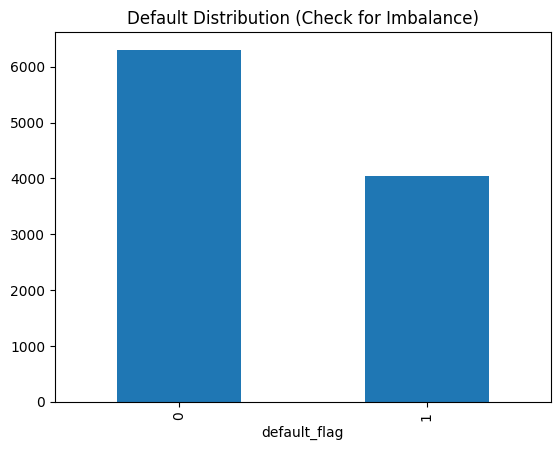

In [64]:
print(dfc['default_flag'].value_counts(normalize=True))
dfc['default_flag'].value_counts().plot(kind='bar')
plt.title('Default Distribution (Check for Imbalance)')
plt.show()

default_flag            1.000000
risk_score              0.399379
repayment_delay_days    0.283209
missed_payments         0.272267
debt_to_income_ratio    0.172947
credit_score           -0.324238
Name: default_flag, dtype: float64


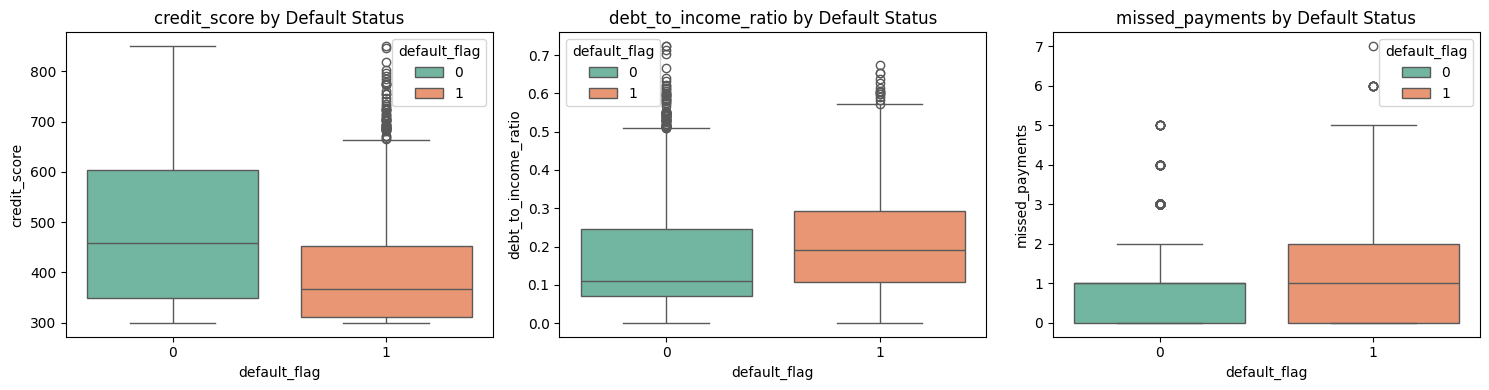

In [65]:
correlations = dfc[['credit_score', 'debt_to_income_ratio', 'risk_score', 
                   'missed_payments', 'repayment_delay_days', 'default_flag']].corr()
print(correlations['default_flag'].sort_values(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['credit_score', 'debt_to_income_ratio', 'missed_payments']

for idx, feature in enumerate(features):
    sns.boxplot(data=dfc, x='default_flag', y=feature, hue = 'default_flag', palette = 'Set2',ax=axes[idx])
    axes[idx].set_title(f'{feature} by Default Status')

plt.tight_layout()
plt.show()

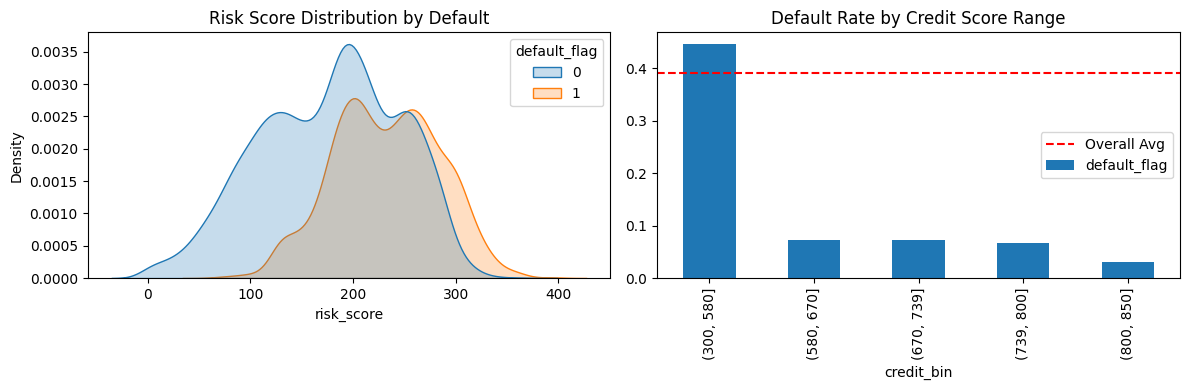

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


sns.kdeplot(data=dfc, x='risk_score', hue='default_flag', fill=True, ax=axes[0])
axes[0].set_title('Risk Score Distribution by Default')


dfc['credit_bin'] = pd.cut(dfc['credit_score'], bins=[300, 580, 670, 739, 800, 850])
credit_default = dfc.groupby('credit_bin', observed=False)['default_flag'].mean()
credit_default.plot(kind='bar', ax=axes[1])
axes[1].set_title('Default Rate by Credit Score Range')
axes[1].axhline(y=dfc['default_flag'].mean(), color='red', linestyle='--', label='Overall Avg')
axes[1].legend()

plt.tight_layout()
plt.show()

                       mean  count
bnpl_installments                 
3                  0.389498   2647
6                  0.374553   2515
9                  0.397866   2624
12                 0.399766   2559


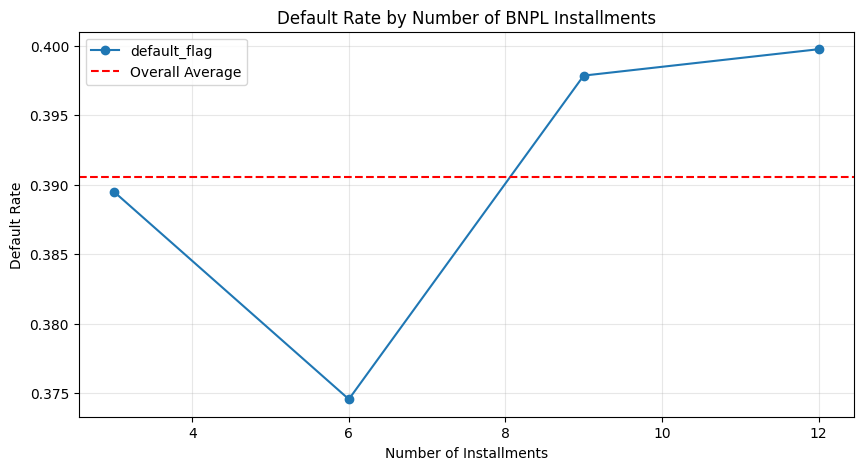

Correlation: 0.012


In [67]:
plt.figure(figsize=(10, 5))


installment_default = dfc.groupby('bnpl_installments')['default_flag'].mean()


installment_stats = dfc.groupby('bnpl_installments')['default_flag'].agg(['mean','count'])
print(installment_stats)


installment_default.plot(marker='o')

plt.title('Default Rate by Number of BNPL Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Default Rate')


plt.axhline(y=dfc['default_flag'].mean(), color='red', linestyle='--', label='Overall Average')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


print(f"Correlation: {dfc['bnpl_installments'].corr(dfc['default_flag']):.3f}")

Missed Payments Stats:
                      mean  count
missed_payments                 
0                0.277268   3704
1                0.375814   3837
2                0.445404   1969
3                0.823890    653
4                0.874126    143
5                0.741935     31
6                1.000000      7
7                1.000000      1

Delay Category Stats:
                     mean  count
delay_category                 
0               0.280558   1219
1-15            0.317392   7193
16-30           0.731846   1928
30+             0.800000      5


<Figure size 1200x400 with 0 Axes>

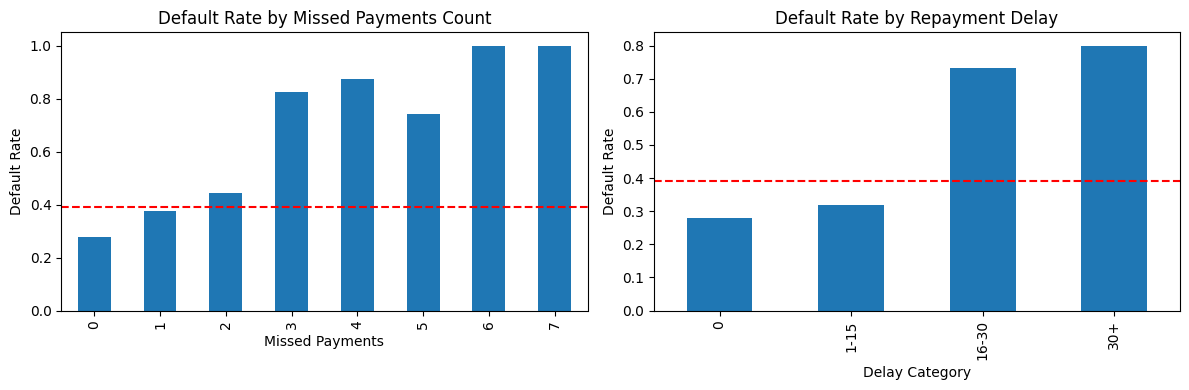

In [68]:
plt.figure(figsize=(12, 4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


missed_group = dfc.groupby('missed_payments')['default_flag'].agg(['mean', 'count'])
print("Missed Payments Stats:\n", missed_group)

# Plot
missed_group['mean'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Default Rate by Missed Payments Count')
axes[0].set_xlabel('Missed Payments')
axes[0].set_ylabel('Default Rate')
axes[0].axhline(y=dfc['default_flag'].mean(), color='red', linestyle='--')


dfc['delay_category'] = pd.cut(
    dfc['repayment_delay_days'], 
    bins=[-1, 0, 15, 30, 999], 
    labels=['0', '1-15', '16-30', '30+']
)

delay_group = dfc.groupby('delay_category', observed=False)['default_flag'].agg(['mean', 'count'])
print("\nDelay Category Stats:\n", delay_group)


delay_group['mean'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Default Rate by Repayment Delay')
axes[1].set_xlabel('Delay Category')
axes[1].set_ylabel('Default Rate')
axes[1].axhline(y=dfc['default_flag'].mean(), color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [69]:
dfc.head(2)

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment,credit_bin,delay_category
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk,"(300.0, 580.0]",1-15
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk,NaN,1-15


DTI Stats:
                mean  count
dti_bin                   
0-0.2      0.332291   6398
0.2-0.36   0.484337   2905
0.36-0.43  0.471986    589
0.43-0.5   0.513699    292
0.5+       0.490683    161


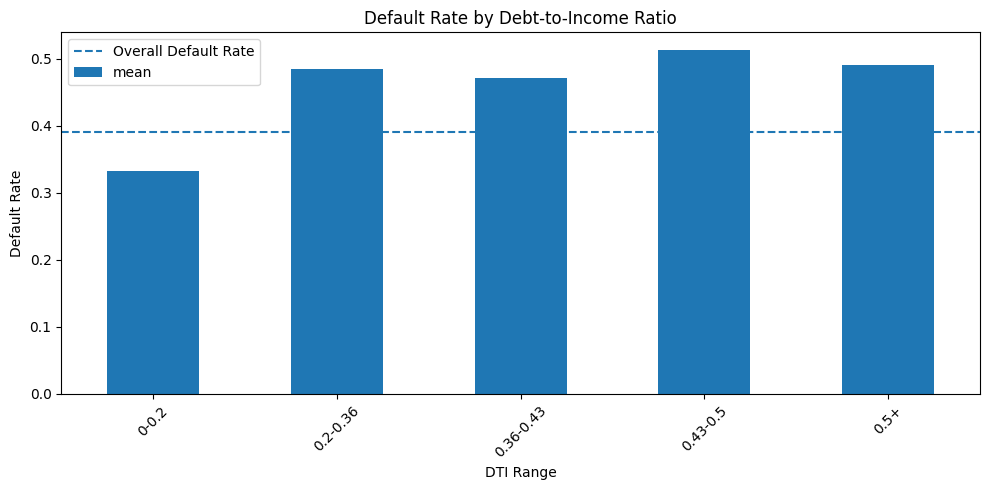


Default rate (DTI > 0.43): 0.506
Default rate (DTI <= 0.36): 0.380


In [70]:
dti_labels = ['0-0.2', '0.2-0.36', '0.36-0.43', '0.43-0.5', '0.5+']
dfc['dti_bin'] = pd.cut(
    dfc['debt_to_income_ratio'],
    bins=[0, 0.2, 0.36, 0.43, 0.5, 1],
    labels=dti_labels
)


dti_stats = dfc.groupby('dti_bin', observed=False)['default_flag'].agg(['mean', 'count'])
print("DTI Stats:\n", dti_stats)


plt.figure(figsize=(10, 5))

dti_stats['mean'].plot(kind='bar')

plt.axhline(
    y=dfc['default_flag'].mean(),
    linestyle='--',
    label='Overall Default Rate'
)

plt.title('Default Rate by Debt-to-Income Ratio')
plt.xlabel('DTI Range')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


high_dti = dfc[dfc['debt_to_income_ratio'] > 0.43]['default_flag'].mean()
low_dti = dfc[dfc['debt_to_income_ratio'] <= 0.36]['default_flag'].mean()

print(f"\nDefault rate (DTI > 0.43): {high_dti:.3f}")
print(f"Default rate (DTI <= 0.36): {low_dti:.3f}")

In [71]:
dfc.head(2)

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment,credit_bin,delay_category,dti_bin
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk,"(300.0, 580.0]",1-15,0-0.2
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk,NaN,1-15,0-0.2


In [72]:
dfc['debt_to_income_ratio'].max()

np.float64(0.723459899101883)

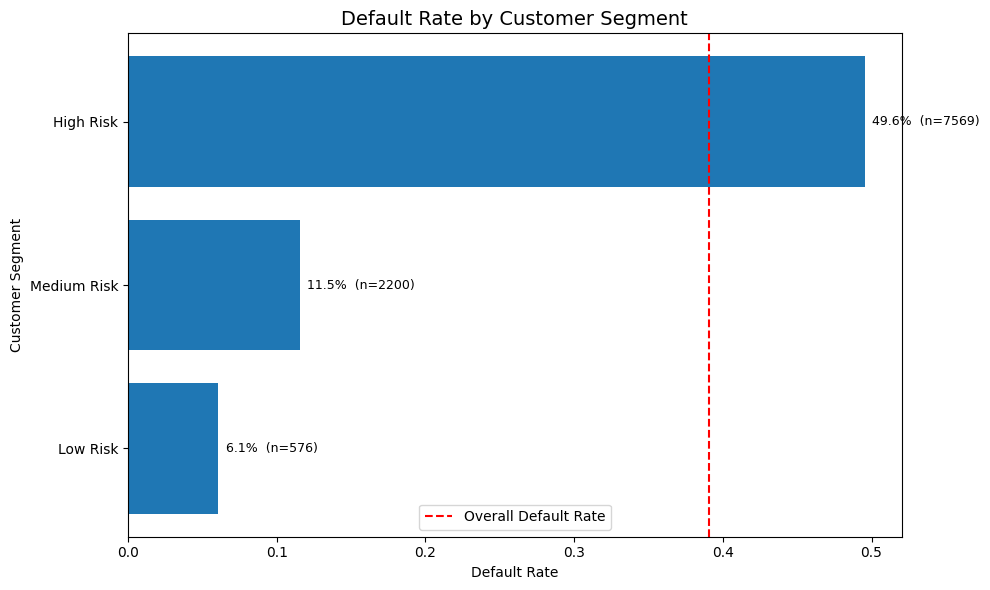

In [73]:
segment_stats = (
    dfc.groupby('customer_segment', observed=False)['default_flag']
       .agg(mean='mean', count='count')
       .sort_values('mean')
)


plt.figure(figsize=(10, 6))

plt.barh(
    segment_stats.index,
    segment_stats['mean']
)

overall_avg = dfc['default_flag'].mean()
plt.axvline(
    x=overall_avg, 
    color='red', 
    linestyle='--', 
    linewidth=1.5, 
    label='Overall Default Rate'
)


plt.title('Default Rate by Customer Segment', fontsize=14)
plt.xlabel('Default Rate')
plt.ylabel('Customer Segment')


for i, (mean, count) in enumerate(zip(segment_stats['mean'], segment_stats['count'])):
    plt.text(
        mean + 0.005,
        i,
        f'{mean:.1%}  (n={count})',
        va='center',
        fontsize=9
    )

plt.legend()
plt.tight_layout()
plt.show()


=== Feature Correlation with Default (Absolute) ===
default_flag            1.000000
risk_score              0.399379
repayment_delay_days    0.283209
missed_payments         0.272267
debt_to_income_ratio    0.172947
bnpl_installments       0.012244
age                    -0.075702
purchase_amount        -0.097912
monthly_income         -0.274163
credit_score           -0.324238
Name: default_flag, dtype: float64


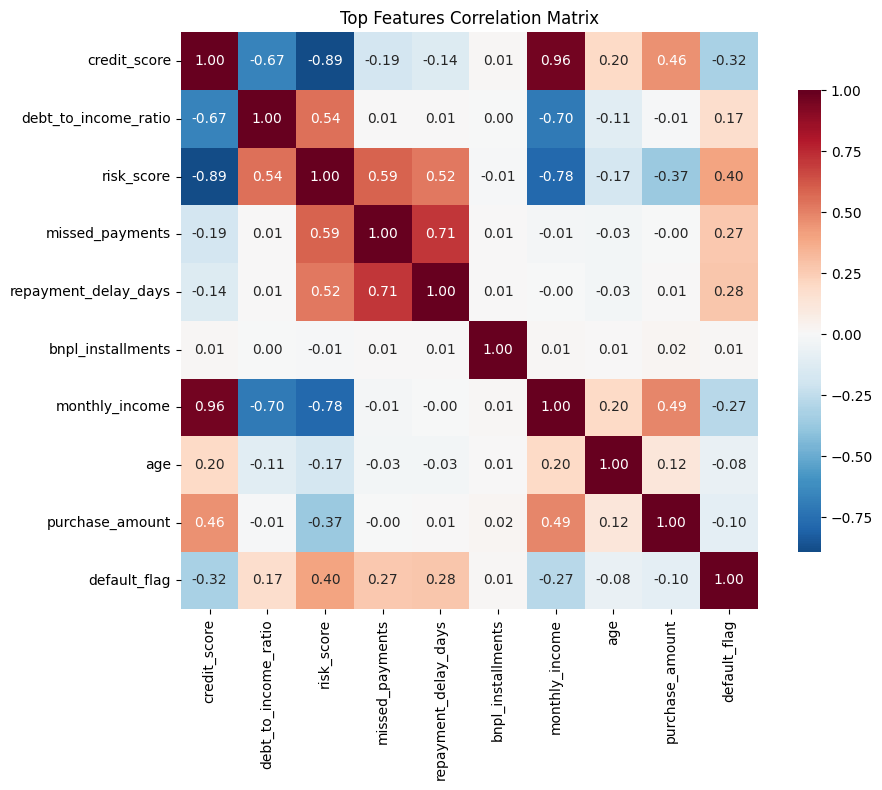

In [74]:
top_features = ['credit_score', 'debt_to_income_ratio', 'risk_score', 
                'missed_payments', 'repayment_delay_days', 'bnpl_installments',
                'monthly_income', 'age', 'purchase_amount', 'default_flag']

corr_matrix = dfc[top_features].corr()


default_corr = corr_matrix['default_flag'].sort_values(ascending=False)
print("\n=== Feature Correlation with Default (Absolute) ===")
print(default_corr)


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Top Features Correlation Matrix')
plt.tight_layout()
plt.show()

In [75]:
summary = dfc.groupby('default_flag', observed = True).agg({
    'credit_score': 'mean',
    'debt_to_income_ratio': 'mean',
    'missed_payments': 'mean',
    'repayment_delay_days': 'mean',
    'risk_score': 'mean',
    'bnpl_installments': 'mean'
}).round(2)

print("\n=== Key Metrics by Default Status ===")
print(summary)


print("\n=== Risk Score Performance ===")
dfc['risk_tier'] = pd.cut(dfc['risk_score'], bins=[0, 30, 50, 70, 100], 
                          labels=['High Risk (0-30)', 'Medium-High (30-50)', 
                                  'Medium-Low (50-70)', 'Low Risk (70-100)'])
risk_performance = dfc.groupby('risk_tier', observed = True)['default_flag'].mean()
print(risk_performance)


=== Key Metrics by Default Status ===
              credit_score  debt_to_income_ratio  missed_payments  \
default_flag                                                        
0                   483.61                  0.16             0.80   
1                   392.88                  0.21             1.35   

              repayment_delay_days  risk_score  bnpl_installments  
default_flag                                                       
0                             7.21      176.94               7.44  
1                            11.14      232.23               7.53  

=== Risk Score Performance ===
risk_tier
High Risk (0-30)       0.000000
Medium-High (30-50)    0.000000
Medium-Low (50-70)     0.004854
Low Risk (70-100)      0.023423
Name: default_flag, dtype: float64


In [76]:
dfc.head(2)

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,...,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment,credit_bin,delay_category,dti_bin,risk_tier
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,...,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk,"(300.0, 580.0]",1-15,0-0.2,NaN
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,...,3.09,USA,2024-10-07,0.148076,266.0,High Risk,NaN,1-15,0-0.2,NaN


In [77]:
dfc.groupby('location')['default_flag'].mean()

location
Australia    0.389082
Canada       0.387931
Germany      0.402841
India        0.380731
UK           0.395433
USA          0.387097
Name: default_flag, dtype: float64

In [78]:
dfc.head(2)

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,...,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment,credit_bin,delay_category,dti_bin,risk_tier
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,...,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk,"(300.0, 580.0]",1-15,0-0.2,NaN
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,...,3.09,USA,2024-10-07,0.148076,266.0,High Risk,NaN,1-15,0-0.2,NaN


In [79]:
dfc.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score',
       'purchase_amount', 'product_category', 'bnpl_installments',
       'repayment_delay_days', 'missed_payments', 'default_flag',
       'app_usage_frequency', 'location', 'transaction_date',
       'debt_to_income_ratio', 'risk_score', 'customer_segment', 'credit_bin',
       'delay_category', 'dti_bin', 'risk_tier'],
      dtype='object')

In [80]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   user_id               10345 non-null  int64   
 1   age                   10345 non-null  int64   
 2   employment_type       10345 non-null  object  
 3   monthly_income        10345 non-null  float64 
 4   credit_score          10345 non-null  int64   
 5   purchase_amount       10345 non-null  float64 
 6   product_category      10345 non-null  object  
 7   bnpl_installments     10345 non-null  int64   
 8   repayment_delay_days  10345 non-null  int64   
 9   missed_payments       10345 non-null  int64   
 10  default_flag          10345 non-null  int64   
 11  app_usage_frequency   10345 non-null  float64 
 12  location              10345 non-null  object  
 13  transaction_date      10345 non-null  object  
 14  debt_to_income_ratio  10345 non-null  float64 
 15  ri

In [81]:
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [82]:
df_clean = dfc.copy()


print("Handling missing values...")
numeric_features = ['credit_score', 'debt_to_income_ratio', 'monthly_income', 'age', 'risk_score']
for col in numeric_features:
    if col in df_clean.columns and df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)


if 'repayment_delay_days' in df_clean.columns and df_clean['repayment_delay_days'].isnull().any():
    df_clean['repayment_delay_days'].fillna(0, inplace=True)
if 'missed_payments' in df_clean.columns and df_clean['missed_payments'].isnull().any():
    df_clean['missed_payments'].fillna(0, inplace=True)


print("Creating engineered features...")
df_clean['payment_compliance'] = 1 - (df_clean['missed_payments'] / (df_clean['bnpl_installments'] + 1))
df_clean['monthly_payment'] = df_clean['purchase_amount'] / df_clean['bnpl_installments']
df_clean['debt_burden'] = df_clean['monthly_payment'] / (df_clean['monthly_income'] + 1)
df_clean['risk_adjusted_credit'] = df_clean['credit_score'] * (1 - df_clean['risk_score'] / 100)
df_clean['high_risk_customer'] = ((df_clean['risk_score'] > 70) | (df_clean['credit_score'] < 580)).astype(int)
df_clean['severe_delinquent'] = (df_clean['repayment_delay_days'] > 30).astype(int)

print("Feature engineering complete!")

Handling missing values...
Creating engineered features...
Feature engineering complete!


In [83]:
original_features = [
    'credit_score', 'debt_to_income_ratio', 'monthly_income',
    'purchase_amount', 'bnpl_installments', 'repayment_delay_days',
    'missed_payments', 'risk_score', 'age'
]

engineered_features = [
    'payment_compliance', 'debt_burden', 'risk_adjusted_credit',
    'high_risk_customer', 'severe_delinquent'
]

final_features = original_features + engineered_features


X = df_clean[final_features].copy()
y = df_clean['default_flag'].copy()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Default rate in training: {y_train.mean():.2%}")
print(f"Default rate in test: {y_test.mean():.2%}")
print(f"\nFeatures used: {X.columns.tolist()}")

Training set size: (8276, 14)
Test set size: (2069, 14)
Default rate in training: 39.05%
Default rate in test: 39.05%

Features used: ['credit_score', 'debt_to_income_ratio', 'monthly_income', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'risk_score', 'age', 'payment_compliance', 'debt_burden', 'risk_adjusted_credit', 'high_risk_customer', 'severe_delinquent']


In [84]:
best_catboost = CatBoostClassifier(
    learning_rate=0.15,
    l2_leaf_reg=3,
    iterations=100,
    depth=7,
    random_state=42,
    verbose=0  
)

best_catboost.fit(X_train, y_train)

y_pred_proba = best_catboost.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)


cv_scores = cross_val_score(best_catboost, X_train, y_train, cv=5, scoring='roc_auc')
test_auc = roc_auc_score(y_test, y_pred_proba)
test_f1 = f1_score(y_test, y_pred)


print("="*50)
print("Tuning CatBoost...")
print("="*50)
print(f"Best parameters: {best_catboost.get_params()}")
print(f"CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Non-Defaulter', 'Defaulter']))

Tuning CatBoost...
Best parameters: {'iterations': 100, 'learning_rate': 0.15, 'depth': 7, 'l2_leaf_reg': 3, 'verbose': 0, 'random_state': 42}
CV AUC: 0.7627 (+/- 0.0072)
Test AUC: 0.7880
Test F1 Score: 0.5680

CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Defaulter       0.72      0.93      0.81      1261
    Defaulter       0.80      0.44      0.57       808

     accuracy                           0.74      2069
    macro avg       0.76      0.69      0.69      2069
 weighted avg       0.75      0.74      0.72      2069



In [85]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("="*70)
print("CLASSIFICATION REPORTS AT DIFFERENT THRESHOLDS")
print("="*70)

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba > threshold).astype(int)
    
    print(f"\n--- THRESHOLD = {threshold} ---")
    print(classification_report(y_test, y_pred_threshold, 
                                target_names=['Non-Defaulter', 'Defaulter'],
                                zero_division=0))
    print(f"AUC remains: {roc_auc_score(y_test, y_pred_proba):.3f}")

CLASSIFICATION REPORTS AT DIFFERENT THRESHOLDS

--- THRESHOLD = 0.3 ---
               precision    recall  f1-score   support

Non-Defaulter       0.93      0.36      0.52      1261
    Defaulter       0.49      0.96      0.65       808

     accuracy                           0.60      2069
    macro avg       0.71      0.66      0.59      2069
 weighted avg       0.76      0.60      0.57      2069

AUC remains: 0.788

--- THRESHOLD = 0.4 ---
               precision    recall  f1-score   support

Non-Defaulter       0.77      0.72      0.74      1261
    Defaulter       0.60      0.66      0.63       808

     accuracy                           0.69      2069
    macro avg       0.68      0.69      0.68      2069
 weighted avg       0.70      0.69      0.70      2069

AUC remains: 0.788

--- THRESHOLD = 0.5 ---
               precision    recall  f1-score   support

Non-Defaulter       0.72      0.93      0.81      1261
    Defaulter       0.80      0.44      0.57       808

     ac

In [86]:
APPROVE_THRESHOLD = 0.30
REJECT_THRESHOLD = 0.60


def hybrid_decision(prob):
    if prob < APPROVE_THRESHOLD:
        return 'APPROVE'
    elif prob < REJECT_THRESHOLD:
        return 'REVIEW'
    else:
        return 'REJECT'

test_results = pd.DataFrame({
    'Actual': y_test,
    'Probability_Default': y_pred_proba
})
test_results['Decision'] = test_results['Probability_Default'].apply(hybrid_decision)

print("="*70)
print(f"HYBRID SYSTEM: APPROVE < {APPROVE_THRESHOLD} | REVIEW {APPROVE_THRESHOLD}-{REJECT_THRESHOLD} | REJECT > {REJECT_THRESHOLD}")
print("="*70)

print("\n DECISION DISTRIBUTION:")
print(test_results['Decision'].value_counts())
print(f"\nTotal customers: {len(test_results)}")

HYBRID SYSTEM: APPROVE < 0.3 | REVIEW 0.3-0.6 | REJECT > 0.6

📊 DECISION DISTRIBUTION:
Decision
REVIEW     1180
APPROVE     493
REJECT      396
Name: count, dtype: int64

Total customers: 2069


In [87]:
print("="*70)
print("PERFORMANCE BY DECISION ZONE")
print("="*70)

for decision in ['APPROVE', 'REVIEW', 'REJECT']:
    zone = test_results[test_results['Decision'] == decision]
    
    if len(zone) > 0:
        if decision == 'APPROVE':
            correct = (zone['Actual'] == 0).sum()
            accuracy = correct / len(zone)
            print(f"\n {decision} ZONE ({len(zone)} customers, {len(zone)/len(test_results)*100:.1f}%):")
            print(f"    Correct approvals: {correct}")
            print(f"    Wrong approvals (defaulters): {len(zone) - correct}")
            print(f"    Approval accuracy: {accuracy:.1%}")
            
        elif decision == 'REJECT':
            correct = (zone['Actual'] == 1).sum()
            accuracy = correct / len(zone)
            print(f"\n {decision} ZONE ({len(zone)} customers, {len(zone)/len(test_results)*100:.1f}%):")
            print(f"    Correct rejections: {correct}")
            print(f"    Wrong rejections (good customers lost): {len(zone) - correct}")
            print(f"    Rejection accuracy: {accuracy:.1%}")
            
        else:  # REVIEW
            default_rate = zone['Actual'].mean()
            print(f"\n {decision} ZONE ({len(zone)} customers, {len(zone)/len(test_results)*100:.1f}%):")
            print(f"    Needs manual review")
            print(f"    Default rate in this zone: {default_rate:.1%}")
            print(f"    Would catch {zone['Actual'].sum()} defaulters via review")

PERFORMANCE BY DECISION ZONE

📗 APPROVE ZONE (493 customers, 23.8%):
   ✅ Correct approvals: 459
   ❌ Wrong approvals (defaulters): 34
   📊 Approval accuracy: 93.1%

📘 REVIEW ZONE (1180 customers, 57.0%):
   🔍 Needs manual review
   ⚠️ Default rate in this zone: 37.6%
   📊 Would catch 444 defaulters via review

📕 REJECT ZONE (396 customers, 19.1%):
   ✅ Correct rejections: 330
   ❌ Wrong rejections (good customers lost): 66
   📊 Rejection accuracy: 83.3%


In [88]:
# Calculate business metrics
auto_approve = test_results[test_results['Decision'] == 'APPROVE']
auto_reject = test_results[test_results['Decision'] == 'REJECT']
manual_review = test_results[test_results['Decision'] == 'REVIEW']

print("="*70)
print("BUSINESS METRICS")
print("="*70)

print(f"\n AUTOMATION RATE: {(len(auto_approve) + len(auto_reject)) / len(test_results):.1%}")
print(f"   • Auto-approved: {len(auto_approve)} ({len(auto_approve)/len(test_results)*100:.1f}%)")
print(f"   • Auto-rejected: {len(auto_reject)} ({len(auto_reject)/len(test_results)*100:.1f}%)")
print(f"   • Manual review: {len(manual_review)} ({len(manual_review)/len(test_results)*100:.1f}%)")

print(f"\n RISK METRICS:")
print(f"   • Bad approvals (defaulters approved): {(auto_approve['Actual'] == 1).sum()}")
print(f"   • Good customers rejected (lost sales): {(auto_reject['Actual'] == 0).sum()}")
print(f"   • Defaulters flagged for review: {manual_review['Actual'].sum()}")

print(f"\n QUALITY METRICS:")
print(f"   • Auto-approval accuracy: {(auto_approve['Actual'] == 0).mean():.1%}")
print(f"   • Auto-rejection accuracy: {(auto_reject['Actual'] == 1).mean():.1%}")

BUSINESS METRICS

🤖 AUTOMATION RATE: 43.0%
   • Auto-approved: 493 (23.8%)
   • Auto-rejected: 396 (19.1%)
   • Manual review: 1180 (57.0%)

💰 RISK METRICS:
   • Bad approvals (defaulters approved): 34
   • Good customers rejected (lost sales): 66
   • Defaulters flagged for review: 444

📊 QUALITY METRICS:
   • Auto-approval accuracy: 93.1%
   • Auto-rejection accuracy: 83.3%


In [89]:
from sklearn.metrics import confusion_matrix

print("="*70)
print("CONFUSION MATRIX - HYBRID SYSTEM")
print("="*70)

hybrid_matrix = pd.DataFrame({
    'Actual\Decision': ['APPROVE', 'REVIEW', 'REJECT', 'TOTAL'],
    'Non-Defaulter (0)': [
        (auto_approve['Actual'] == 0).sum(),
        (manual_review['Actual'] == 0).sum(),
        (auto_reject['Actual'] == 0).sum(),
        (y_test == 0).sum()
    ],
    'Defaulter (1)': [
        (auto_approve['Actual'] == 1).sum(),
        (manual_review['Actual'] == 1).sum(),
        (auto_reject['Actual'] == 1).sum(),
        (y_test == 1).sum()
    ]
})

print("\n", hybrid_matrix.to_string(index=False))

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print(f" SAFE: {hybrid_matrix.loc[0, 'Non-Defaulter (0)']} good customers auto-approved")
print(f"  RISKY: {hybrid_matrix.loc[0, 'Defaulter (1)']} defaulters wrongly auto-approved")
print(f" REVIEW: {hybrid_matrix.loc[1, 'Defaulter (1)']} defaulters sent to manual review")
print(f" LOST: {hybrid_matrix.loc[2, 'Non-Defaulter (0)']} good customers wrongly rejected")

CONFUSION MATRIX - HYBRID SYSTEM

 Actual\Decision  Non-Defaulter (0)  Defaulter (1)
        APPROVE                459             34
         REVIEW                736            444
         REJECT                 66            330
          TOTAL               1261            808

INTERPRETATION:
✅ SAFE: 459 good customers auto-approved
⚠️  RISKY: 34 defaulters wrongly auto-approved
🔍 REVIEW: 444 defaulters sent to manual review
❌ LOST: 66 good customers wrongly rejected


In [90]:
joblib.dump(best_catboost, 'bnpl_hybrid_model.pkl')


with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)


threshold_config = {
    'approve_threshold': 0.30,
    'reject_threshold': 0.60,
    'model_type': 'CatBoost'
}

with open('threshold_config.json', 'w') as f:
    json.dump(threshold_config, f)

print("CatBoost model and configuration saved successfully!")
print("Files saved: bnpl_hybrid_model.pkl, feature_names.pkl, threshold_config.json")

✅ CatBoost model and configuration saved successfully!
📁 Files saved: bnpl_hybrid_model.pkl, feature_names.pkl, threshold_config.json
